In [1]:
import navis
import os 
import pandas as pd
from scipy.spatial import cKDTree
from tqdm import tqdm

/lmb/home/yyin/miniconda3/envs/flyconnectome/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
prefix = "720575940"
folder = '/cephfs2/yyin/ad_split'

# get data

In [3]:
sk_path = os.path.join(folder, "sk_lod1_783_healed")
skids = os.listdir(sk_path)
len(skids)

139273

In [4]:
meta = pd.read_csv('https://raw.githubusercontent.com/YijieYin/connectome_data_prep/refs/heads/main/data/fafb_all_neuron/fafb_all_neuron_meta.csv', index_col=0)
meta.loc[:, ["root_id_short"]] = meta.root_id.apply(
    lambda x: int(str(x).split(prefix)[1])
)
id2type = dict(zip(meta.root_id, meta.cell_type))
short_id2type = dict(zip(meta.root_id_short, meta.cell_type))
meta

<ipython-input-4-c2263b2a79b1>:1: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv('https://raw.githubusercontent.com/YijieYin/connectome_data_prep/refs/heads/main/data/fafb_all_neuron/fafb_all_neuron_meta.csv', index_col=0)


,root_id,cell_type,side,top_nt,super_class,cell_class,cell_sub_class,ito_lee_hemilineage,hartenstein_hemilineage,idx,sign,coords,root_id_short
0,720575940628857210,PS180,left,acetylcholine,central,NaN,NaN,SMPpv2_ventral,CP1_ventral,90900,1,NaN,628857210
1,720575940626838909,CB0924,right,acetylcholine,central,NaN,NaN,VLPl2_medial,BLAv2_medial,78909,1,NaN,626838909
2,720575940626046919,AVLP429,right,acetylcholine,central,NaN,NaN,putative_primary,NaN,74855,1,NaN,626046919
3,720575940630311383,AVLP151,right,acetylcholine,central,NaN,NaN,putative_primary,putative_primary,98344,1,NaN,630311383
4,720575940633370649,LC27,right,acetylcholine,visual_projection,NaN,NaN,NaN,NaN,112637,1,NaN,633370649
...,...,...,...,...,...,...,...,...,...,...,...,...,...
139237,720575940618571494,MLt7,right,acetylcholine,optic,ME>LO,NaN,NaN,NaN,35797,1,NaN,618571494
139238,720575940633170572,Li02,right,acetylcholine,optic,LO,NaN,NaN,NaN,111842,1,NaN,633170572
139239,720575940650339961,Li02,right,acetylcholine,optic,LO,NaN,NaN,NaN,137234,1,NaN,650339961
139240,720575940619997854,MTe51,left,acetylcholine,optic,ME>LO,NaN,NaN,NaN,41495,1,NaN,619997854


In [5]:
meta.super_class.value_counts()

super_class
optic                 77524
central               32382
sensory               16771
visual_projection      8037
ascending              1750
descending             1303
sensory_ascending       612
visual_centrifugal      524
motor                   110
endocrine                80
Name: count, dtype: int64

In [6]:
syn = pd.read_csv(os.path.join(folder, "fafb_v783_princeton_synapse_table.csv"))
# remove autapses 
syn = syn[syn.pre_root_id_720575940 != syn.post_root_id_720575940]
syn

,pre_x,pre_y,pre_z,ctr_x,ctr_y,ctr_z,post_x,post_y,post_z,size,pre_root_id_720575940,post_root_id_720575940,neuropil
0,96224,405424,165280,96112,405424,165400,96000,405392,165360,103,610757204,620797269,LA_L
1,104880,267168,191400,104960,267296,191400,104880,267312,191360,33,631658191,615542890,NaN
3,104880,396160,153840,104880,396080,153840,104800,396032,153800,11,623232681,646119534,LA_L
4,106544,418032,165680,106494,418251,165714,106480,418064,165840,84,629884163,617986619,LA_L
5,108384,422256,165800,108560,422384,165760,108352,422416,165840,159,624965047,627177022,LA_L
...,...,...,...,...,...,...,...,...,...,...,...,...,...
80215781,883440,294288,129600,883552,294256,129520,883584,294240,129600,124,629545371,631721721,LA_R
80215784,887872,292864,144320,887888,292752,144240,887744,292768,144200,20,606015776,609178051,LA_R
80215785,888240,292640,154120,888256,292768,154080,888240,292800,153960,29,636344431,613032854,LA_R
80215786,883856,259136,144160,883872,259248,144320,883712,259296,144280,108,619707003,625969098,LA_R


In [7]:
syn['pre_type'] = syn.pre_root_id_720575940.map(short_id2type)
syn['post_type'] = syn.post_root_id_720575940.map(short_id2type)
syn

,pre_x,pre_y,pre_z,ctr_x,ctr_y,ctr_z,post_x,post_y,post_z,size,pre_root_id_720575940,post_root_id_720575940,neuropil,pre_type,post_type
0,96224,405424,165280,96112,405424,165400,96000,405392,165360,103,610757204,620797269,LA_L,R1-6,720575940620797269
1,104880,267168,191400,104960,267296,191400,104880,267312,191360,33,631658191,615542890,NaN,R1-6,R1-6
3,104880,396160,153840,104880,396080,153840,104800,396032,153800,11,623232681,646119534,LA_L,720575940623232681,L2
4,106544,418032,165680,106494,418251,165714,106480,418064,165840,84,629884163,617986619,LA_L,R1-6,720575940617986619
5,108384,422256,165800,108560,422384,165760,108352,422416,165840,159,624965047,627177022,LA_L,R1-6,720575940627177022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80215781,883440,294288,129600,883552,294256,129520,883584,294240,129600,124,629545371,631721721,LA_R,Lawf2,Lai
80215784,887872,292864,144320,887888,292752,144240,887744,292768,144200,20,606015776,609178051,LA_R,Lawf2,C2
80215785,888240,292640,154120,888256,292768,154080,888240,292800,153960,29,636344431,613032854,LA_R,Lawf1,L3
80215786,883856,259136,144160,883872,259248,144320,883712,259296,144280,108,619707003,625969098,LA_R,Lawf2,C2


## CX synapse count

In [ ]:
cxpresyns = syn[syn.pre_type.isin(meta.cell_type[meta.cell_class == 'CX'])].replace({'neuropil': {'GA_L': 'GA', 'GA_R': 'GA'}})
cxpostsyns = syn[syn.post_type.isin(meta.cell_type[meta.cell_class == 'CX'])].replace({'neuropil': {'GA_L': 'GA', 'GA_R': 'GA'}})

In [ ]:
cxpre_np = cxpresyns.groupby(['pre_type','neuropil']).size().reset_index(name='counts')
# remove pre_type where pre_type is actually str(int)
cxpre_np = cxpre_np[~cxpre_np.pre_type.str.isdigit()]
cxpre_syncount = cxpresyns.groupby(['pre_type']).size()
cxpre_np['pre_total'] = cxpre_np.pre_type.map(cxpre_syncount)
cxpre_np['pre_fraction'] = cxpre_np['counts'] / cxpre_np['pre_total']
# fraction of presynapses in each neuropil
cxpre_np_fraction = cxpre_np[cxpre_np.neuropil.isin(['PB','FB','EB','NO', 'GA'])].pivot(index='pre_type', columns='neuropil', values='pre_fraction',).fillna(0).sort_index()
cxpre_np_fraction.to_csv('cxpre_np_fraction.csv')

In [ ]:
cxpost_np = cxpostsyns.groupby(['post_type','neuropil']).size().reset_index(name='counts')
# remove post_type where post_type is actually str(int)
cxpost_np = cxpost_np[~cxpost_np.post_type.str.isdigit()]
cxpost_syncount = cxpostsyns.groupby(['post_type']).size()
cxpost_np['post_total'] = cxpost_np.post_type.map(cxpost_syncount)
cxpost_np['post_fraction'] = cxpost_np['counts'] / cxpost_np['post_total']
cxpost_np_fraction = cxpost_np[cxpost_np.neuropil.isin(['PB','FB','EB','NO', 'GA'])].pivot(index='post_type', columns='neuropil', values='post_fraction',).fillna(0).sort_index()
cxpost_np_fraction.to_csv('cxpost_np_fraction.csv')

In [ ]:
cx_np = cxpre_np.merge(cxpost_np, left_on=['neuropil','pre_type'], right_on=['neuropil','post_type'], suffixes=('_pre','_post'))
cx_np['pre_over_post_str'] = cx_np['counts_pre'].astype(str) + " / " + cx_np['counts_post'].astype(str)
cx_np['pre_over_post'] = cx_np['counts_pre'] / cx_np['counts_post']
cx_np[cx_np.neuropil.isin(['PB','FB','EB','NO', 'GA'])].pivot(index='pre_type', columns='neuropil', values='pre_over_post').to_csv('cxprepost_np_counts.csv')

In [ ]:
syn.groupby(['pre_root_id_720575940', 'post_root_id_720575940']).size().reset_index(name='syn_count')

# manually split 
## KC 

In [ ]:
kc_shortids = meta.loc[meta.cell_class == "Kenyon_Cell", "root_id_short"].values
kc_syns = syn[syn.pre_root_id_720575940.isin(kc_shortids) | syn.post_root_id_720575940.isin(kc_shortids)]

In [ ]:
kc_syns.neuropil.value_counts()

dendrites: 
CA, LH, PLP, SCL, ICL, SLP, PB, LO, ATL

In [ ]:
kc_syns.loc[:,['compartment']] = kc_syns.neuropil.apply(
    lambda x: "dendrite" if x in ["MB_CA_L", 'MB_CA_R', "LH_L", 'LH_R', "PLP_L", 'PLP_R',
                                  "SCL_L", 'SCL_R', "ICL_L", "ICL_R", "SLP_L", 'SLP_R', 
                                  "PB", "LO_L", 'LO_R', "ATL_L", 'ATL_R'] else "axon"
)

In [ ]:
for kcid in tqdm(meta.root_id_short[meta.cell_class == "Kenyon_Cell"].values):
    axon_out = kc_syns.loc[(kc_syns.pre_root_id_720575940 == kcid) & (kc_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(kcid)}.csv"), index=False)
    axon_in = kc_syns.loc[(kc_syns.post_root_id_720575940 == kcid) & (kc_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(kcid)}.csv"), index=False)
    dendrite_out = kc_syns.loc[(kc_syns.pre_root_id_720575940 == kcid) & (kc_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(kcid)}.csv"), index=False)
    dendrite_in = kc_syns.loc[(kc_syns.post_root_id_720575940 == kcid) & (kc_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(kcid)}.csv"), index=False)



## tangential neurons

In [59]:
tan_shortids = meta.loc[(meta.cell_sub_class == "tangential") 
& (meta.super_class == 'central') 
# FB intrinsic types, not spliting 
& (~meta.cell_type.isin(['FB4Z', 'FB5R,FB5U', 'FB5S', 'FB6,FB6J', 'FB4Z', 'FB6L', 'FB7D', 'FB7J'])), 
"root_id_short"].values
tan_syns = syn[syn.pre_root_id_720575940.isin(tan_shortids) | syn.post_root_id_720575940.isin(tan_shortids)]

In [ ]:
tan_syns.neuropil.value_counts().reset_index().neuropil.values

axons: FB, NO

In [ ]:
tan_syns.loc[:,['compartment']] = tan_syns.neuropil.apply(
    lambda x: "axon" if x in ["FB",'NO'] else "dendrite"
)

In [ ]:
for tanid in tqdm(tan_shortids):
    axon_out = tan_syns.loc[(tan_syns.pre_root_id_720575940 == tanid) & (tan_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(tanid)}.csv"), index=False)
    axon_in = tan_syns.loc[(tan_syns.post_root_id_720575940 == tanid) & (tan_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(tanid)}.csv"), index=False)
    dendrite_out = tan_syns.loc[(tan_syns.pre_root_id_720575940 == tanid) & (tan_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(tanid)}.csv"), index=False)
    dendrite_in = tan_syns.loc[(tan_syns.post_root_id_720575940 == tanid) & (tan_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(tanid)}.csv"), index=False)



## FR, FS, FC

In [ ]:
frsc_shortids = meta.loc[meta.cell_type.str.contains('^FR') | meta.cell_type.str.contains('FS') | meta.cell_type.str.contains('FC'), "root_id_short"].values
frsc_syns = syn[syn.pre_root_id_720575940.isin(frsc_shortids) | syn.post_root_id_720575940.isin(frsc_shortids)]

In [ ]:
frsc_syns.neuropil.value_counts().reset_index()

In [ ]:
frsc_syns.loc[:,['compartment']] = frsc_syns.neuropil.apply(
    lambda x: "dendrite" if x in ["FB"] else "axon"
)

In [ ]:
for frscid in tqdm(frsc_shortids):
    axon_out = frsc_syns.loc[(frsc_syns.pre_root_id_720575940 == frscid) & (frsc_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(frscid)}.csv"), index=False)
    axon_in = frsc_syns.loc[(frsc_syns.post_root_id_720575940 == frscid) & (frsc_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(frscid)}.csv"), index=False)
    dendrite_out = frsc_syns.loc[(frsc_syns.pre_root_id_720575940 == frscid) & (frsc_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(frscid)}.csv"), index=False)
    dendrite_in = frsc_syns.loc[(frsc_syns.post_root_id_720575940 == frscid) & (frsc_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(frscid)}.csv"), index=False)




## SA1-3

In [ ]:
sa123_shortids = meta.loc[meta.cell_type.isin(['SA1', 'SA2', 'SA3']), 'root_id_short'].values
sa123_syns = syn[syn.pre_root_id_720575940.isin(sa123_shortids) | syn.post_root_id_720575940.isin(sa123_shortids)]

In [ ]:
sa123_syns.neuropil.value_counts().reset_index()

axon: FB and NO

In [ ]:
sa123_syns.loc[:,['compartment']] = sa123_syns.neuropil.apply(
    lambda x: "axon" if x in ["FB", 'NO'] else "dendrite"
)

In [ ]:
for sa123id in tqdm(sa123_shortids):
    axon_out = sa123_syns.loc[(sa123_syns.pre_root_id_720575940 == sa123id) & (sa123_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(sa123id)}.csv"), index=False)
    axon_in = sa123_syns.loc[(sa123_syns.post_root_id_720575940 == sa123id) & (sa123_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(sa123id)}.csv"), index=False)
    dendrite_out = sa123_syns.loc[(sa123_syns.pre_root_id_720575940 == sa123id) & (sa123_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(sa123id)}.csv"), index=False)
    dendrite_in = sa123_syns.loc[(sa123_syns.post_root_id_720575940 == sa123id) & (sa123_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(sa123id)}.csv"), index=False)

    

## ExR5

In [ ]:
exr5_shortids = meta.loc[meta.cell_type == 'ExR5', "root_id_short"].values
exr5_syns = syn[syn.pre_root_id_720575940.isin(exr5_shortids) | syn.post_root_id_720575940.isin(exr5_shortids)]

In [ ]:
exr5_syns.neuropil.value_counts().reset_index().neuropil.values

dendrites: SPS, IB, ICL, PLP, IPS, ATL, PB

In [ ]:
exr5_syns.loc[:,['compartment']] = exr5_syns.neuropil.apply(
    lambda x: "dendrite" if x in ["SPS_L", 'SPS_R', 'IB_L', 'IB_R', 'ICL_L', 'ICL_R', 'PLP_R', 'PLP_L', 'IPS_R', 'IPS_L', 'ATL_R', 'ATL_L', 'PB'] else "axon"
)

In [ ]:
for exr5id in tqdm(exr5_shortids):
    axon_out = exr5_syns.loc[(exr5_syns.pre_root_id_720575940 == exr5id) & (exr5_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(exr5id)}.csv"), index=False)
    axon_in = exr5_syns.loc[(exr5_syns.post_root_id_720575940 == exr5id) & (exr5_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(exr5id)}.csv"), index=False)
    dendrite_out = exr5_syns.loc[(exr5_syns.pre_root_id_720575940 == exr5id) & (exr5_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(exr5id)}.csv"), index=False)
    dendrite_in = exr5_syns.loc[(exr5_syns.post_root_id_720575940 == exr5id) & (exr5_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(exr5id)}.csv"), index=False)

    

## ExR1

In [56]:
exr1_shortids = meta.loc[meta.cell_type == 'ExR1', "root_id_short"].values
exr1_syns = syn[syn.pre_root_id_720575940.isin(exr1_shortids) | syn.post_root_id_720575940.isin(exr1_shortids)]

In [57]:
exr1_syns.neuropil.value_counts().reset_index().neuropil.values

array(['EB', 'FB', 'CRE_R', 'CRE_L', 'BU_R', 'GA_L', 'GA_R', 'BU_L',
       'MB_ML_R', 'MB_ML_L', 'MB_PED_L', 'LAL_L', 'LAL_R', 'SMP_L',
       'ICL_R', 'SIP_R', 'MB_PED_R', 'SIP_L', 'PB', 'IB_L', 'SPS_L',
       'GOR_L', 'IB_R', 'MB_VL_R', 'ATL_R', 'GOR_R', 'PVLP_L'],
      dtype=object)

axon: EB

In [ ]:
exr1_syns.loc[:,['compartment']] = exr1_syns.neuropil.apply(
    lambda x: "axon" if x in ["EB"] else "dendrite"
)

In [ ]:
for exr1id in tqdm(exr1_shortids):
    axon_out = exr1_syns.loc[(exr1_syns.pre_root_id_720575940 == exr1id) & (exr1_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(exr1id)}.csv"), index=False)
    axon_in = exr1_syns.loc[(exr1_syns.post_root_id_720575940 == exr1id) & (exr1_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(exr1id)}.csv"), index=False)
    dendrite_out = exr1_syns.loc[(exr1_syns.pre_root_id_720575940 == exr1id) & (exr1_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(exr1id)}.csv"), index=False)
    dendrite_in = exr1_syns.loc[(exr1_syns.post_root_id_720575940 == exr1id) & (exr1_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(exr1id)}.csv"), index=False)

    

## ring neurons

In [ ]:
ring_shortids = meta.loc[meta.cell_sub_class == 'ring neuron', "root_id_short"].values
ring_syns = syn[syn.pre_root_id_720575940.isin(ring_shortids) | syn.post_root_id_720575940.isin(ring_shortids)]

In [ ]:
ring_syns.neuropil.value_counts().reset_index().neuropil.values

axon: EB 

In [ ]:
ring_syns.loc[:,['compartment']] = ring_syns.neuropil.apply(
    lambda x: "axon" if x in ['EB'] else "dendrite"
)

In [ ]:
for ringid in tqdm(ring_shortids):
    axon_out = ring_syns.loc[(ring_syns.pre_root_id_720575940 == ringid) & (ring_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(ringid)}.csv"), index=False)
    axon_in = ring_syns.loc[(ring_syns.post_root_id_720575940 == ringid) & (ring_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(ringid)}.csv"), index=False)
    dendrite_out = ring_syns.loc[(ring_syns.pre_root_id_720575940 == ringid) & (ring_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(ringid)}.csv"), index=False)
    dendrite_in = ring_syns.loc[(ring_syns.post_root_id_720575940 == ringid) & (ring_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(ringid)}.csv"), index=False)

    

## PFN

In [ ]:
pfn_shortids = meta.loc[meta.cell_type.str.contains('PFN'), "root_id_short"].values
pfn_syns = syn[syn.pre_root_id_720575940.isin(pfn_shortids) | syn.post_root_id_720575940.isin(pfn_shortids)]

In [ ]:
pfn_syns.neuropil.value_counts().reset_index().neuropil.values

FB is the only neuropil with presynapses > postsynapses, so FB axons, otherwise dendrite. 

In [ ]:
pfn_syns.loc[:,['compartment']] = pfn_syns.neuropil.apply(
    lambda x: "axon" if x in ['FB'] else "dendrite"
)

In [ ]:
for pfnid in tqdm(pfn_shortids):
    axon_out = pfn_syns.loc[(pfn_syns.pre_root_id_720575940 == pfnid) & (pfn_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(pfnid)}.csv"), index=False)
    axon_in = pfn_syns.loc[(pfn_syns.post_root_id_720575940 == pfnid) & (pfn_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(pfnid)}.csv"), index=False)
    dendrite_out = pfn_syns.loc[(pfn_syns.pre_root_id_720575940 == pfnid) & (pfn_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(pfnid)}.csv"), index=False)
    dendrite_in = pfn_syns.loc[(pfn_syns.post_root_id_720575940 == pfnid) & (pfn_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(pfnid)}.csv"), index=False)

    

## PEN

In [ ]:
pen_shortids = meta.loc[meta.cell_type.str.contains('PEN'), "root_id_short"].values
pen_syns = syn[syn.pre_root_id_720575940.isin(pen_shortids) | syn.post_root_id_720575940.isin(pen_shortids)]

In [ ]:
pen_syns.neuropil.value_counts().reset_index().neuropil.values

EB is the only neuropil with presynapses > postsynapses, so EB axons, otherwise dendrite. 

In [ ]:
pen_syns.loc[:,['compartment']] = pen_syns.neuropil.apply(
    lambda x: "axon" if x in ['EB'] else "dendrite"
)

In [ ]:
for penid in tqdm(pen_shortids):
    axon_out = pen_syns.loc[(pen_syns.pre_root_id_720575940 == penid) & (pen_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(penid)}.csv"), index=False)
    axon_in = pen_syns.loc[(pen_syns.post_root_id_720575940 == penid) & (pen_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(penid)}.csv"), index=False)
    dendrite_out = pen_syns.loc[(pen_syns.pre_root_id_720575940 == penid) & (pen_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(penid)}.csv"), index=False)
    dendrite_in = pen_syns.loc[(pen_syns.post_root_id_720575940 == penid) & (pen_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(penid)}.csv"), index=False)

    

## EPG

In [ ]:
epg_shortids = meta.loc[meta.cell_type == 'EPG', "root_id_short"].values
epg_syns = syn[syn.pre_root_id_720575940.isin(epg_shortids) | syn.post_root_id_720575940.isin(epg_shortids)]

In [ ]:
epg_syns.neuropil.value_counts().reset_index().neuropil.values

dendrites in EB

In [ ]:
epg_syns.loc[:,['compartment']] = epg_syns.neuropil.apply(
    lambda x: "dendrite" if x in ['EB'] else "axon"
)

In [ ]:
for epgid in tqdm(epg_shortids):
    axon_out = epg_syns.loc[(epg_syns.pre_root_id_720575940 == epgid) & (epg_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(epgid)}.csv"), index=False)
    axon_in = epg_syns.loc[(epg_syns.post_root_id_720575940 == epgid) & (epg_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(epgid)}.csv"), index=False)
    dendrite_out = epg_syns.loc[(epg_syns.pre_root_id_720575940 == epgid) & (epg_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(epgid)}.csv"), index=False)
    dendrite_in = epg_syns.loc[(epg_syns.post_root_id_720575940 == epgid) & (epg_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(epgid)}.csv"), index=False)

    

## PEG

In [ ]:
peg_shortids = meta.loc[meta.cell_type.str.contains('PEG'), "root_id_short"].values
peg_syns = syn[syn.pre_root_id_720575940.isin(peg_shortids) | syn.post_root_id_720575940.isin(peg_shortids)]

In [ ]:
peg_syns.neuropil.value_counts().reset_index().neuropil.values

dendrite in PB

In [ ]:
peg_syns.loc[:,['compartment']] = peg_syns.neuropil.apply(
    lambda x: "dendrite" if x in ['PB'] else "axon"
)

In [ ]:
for pegid in tqdm(peg_shortids):
    axon_out = peg_syns.loc[(peg_syns.pre_root_id_720575940 == pegid) & (peg_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(pegid)}.csv"), index=False)
    axon_in = peg_syns.loc[(peg_syns.post_root_id_720575940 == pegid) & (peg_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(pegid)}.csv"), index=False)
    dendrite_out = peg_syns.loc[(peg_syns.pre_root_id_720575940 == pegid) & (peg_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(pegid)}.csv"), index=False)
    dendrite_in = peg_syns.loc[(peg_syns.post_root_id_720575940 == pegid) & (peg_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(pegid)}.csv"), index=False)

    

## PFL & PFR & PFGs

In [ ]:
pflr_shortids = meta.loc[meta.cell_type.str.contains('PFL|PFR|PFGs'), "root_id_short"].values
pflr_syns = syn[syn.pre_root_id_720575940.isin(pflr_shortids) | syn.post_root_id_720575940.isin(pflr_shortids)]

In [ ]:
pflr_syns.neuropil.value_counts().reset_index()

axons in LAL and 'R' and GA

In [ ]:
pflr_syns.loc[:,['compartment']] = pflr_syns.neuropil.apply(
    lambda x: "dendrite" if x in ['FB', 'PB'] else "axon"
)

In [ ]:
for pflrid in tqdm(pflr_shortids):
    axon_out = pflr_syns.loc[(pflr_syns.pre_root_id_720575940 == pflrid) & (pflr_syns.compartment == "axon")]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(pflrid)}.csv"), index=False)
    axon_in = pflr_syns.loc[(pflr_syns.post_root_id_720575940 == pflrid) & (pflr_syns.compartment == "axon")]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(pflrid)}.csv"), index=False)
    dendrite_out = pflr_syns.loc[(pflr_syns.pre_root_id_720575940 == pflrid) & (pflr_syns.compartment == "dendrite")]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(pflrid)}.csv"), index=False)
    dendrite_in = pflr_syns.loc[(pflr_syns.post_root_id_720575940 == pflrid) & (pflr_syns.compartment == "dendrite")]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(pflrid)}.csv"), index=False)

    

## the rest 
sensory & ascending: all axons;  
motor: all dendrites

In [ ]:
# sens_asc 
sens_asc = meta[meta.super_class.isin(['sensory','ascending', 'sensory_ascending'])].root_id_short.values
sens_asc_syns = syn[syn.pre_root_id_720575940.isin(sens_asc) | syn.post_root_id_720575940.isin(sens_asc)]
sens_asc_syns.loc[:,['compartment']] = 'axon'
for sid in tqdm(sens_asc):
    axon_out = sens_asc_syns.loc[(sens_asc_syns.pre_root_id_720575940 == sid)]
    axon_out = axon_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    axon_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_out", f"{prefix}{str(sid)}.csv"), index=False)
    axon_in = sens_asc_syns.loc[(sens_asc_syns.post_root_id_720575940 == sid)]
    axon_in = axon_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    axon_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "axon_in", f"{prefix}{str(sid)}.csv"), index=False)

    

In [ ]:
# motor 
motor = meta[meta.super_class.isin(['motor']) & (meta.cell_type != 'CB0769')].root_id_short.values
motor_syns = syn[syn.pre_root_id_720575940.isin(motor) | syn.post_root_id_720575940.isin(motor)]
motor_syns.loc[:,['compartment']] = 'dendrite'
for mid in tqdm(motor):
    dendrite_out = motor_syns.loc[(motor_syns.pre_root_id_720575940 == mid)]
    dendrite_out = dendrite_out.rename(
        columns={"pre_x": "x", "pre_y": "y", "pre_z": "z", "post_x": "partner_x", 
                 "post_y": "partner_y", "post_z": "partner_z"},)
    dendrite_out[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_out", f"{prefix}{str(mid)}.csv"), index=False)
    dendrite_in = motor_syns.loc[(motor_syns.post_root_id_720575940 == mid)]
    dendrite_in = dendrite_in.rename(
        columns={"post_x": "x", "post_y": "y", "post_z": "z", "pre_x": "partner_x", 
                 "pre_y": "partner_y", "pre_z": "partner_z"},)
    dendrite_in[['x', 'y', 'z', 'neuropil', 'pre_root_id_720575940', 'post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']].to_csv(os.path.join(folder, "dendrite_in", f"{prefix}{str(mid)}.csv"), index=False)

# segregation index

In [ ]:
seg_idx = []
for dir in tqdm(os.listdir(os.path.join(folder, "seg_indices"))): 
    seg_idx.append(pd.read_csv(os.path.join(folder, "seg_indices", dir), index_col=0))

seg_idx = pd.concat(seg_idx, axis=0).reset_index()
seg_idx['cell_type'] = seg_idx.root_id.map(id2type)
seg_idx

 24%|██▍       | 27754/114655 [16:54<52:14, 27.72it/s]  

<Axes: >

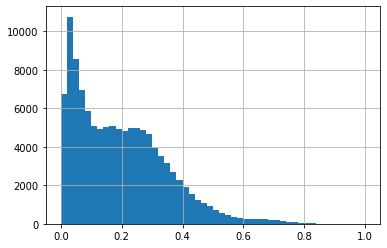

In [9]:
seg_idx.segregation_index.hist(bins = 50)

In [10]:
seg_idx_type = seg_idx.groupby('cell_type').segregation_index.mean().sort_values(ascending=False).reset_index()
seg_idx_type 

,cell_type,segregation_index
0,720575940634572384,1.000000e+00
1,DNge153,1.000000e+00
2,720575940623544285,1.000000e+00
3,720575940626719434,1.000000e+00
4,720575940631813839,1.000000e+00
...,...,...
8773,lLN2F_a,6.442355e-04
8774,lLN2F_b,6.290901e-04
8775,Li32,5.612140e-04
8776,CT1,4.853880e-04


In [67]:
seg_idx_type[seg_idx_type.cell_type.isin(meta.cell_type[meta.cell_class == 'CX']) & (seg_idx_type.segregation_index < 0.05)]

,cell_type,segregation_index
7792,"FB7G,FB7I",0.048406
7798,vDeltaJ,0.048252
7847,ExR2_2,0.046052
7855,FB2D,0.045854
7929,ER2,0.042420
7930,720575940633456409,0.042404
8001,FB2I_a,0.039318
8069,FB2B_b,0.036091
8100,FC2A,0.035138
8121,FB8F_a,0.034386


In [54]:
seg_idx_type[seg_idx_type.cell_type.str.contains('vDelta')]

,cell_type,segregation_index
4139,vDeltaA_b,0.186983
5360,vDeltaB,0.136676
5722,"vDeltaG,vDeltaH",0.123650
6175,vDeltaC,0.105632
6292,vDeltaM,0.101671
6700,vDeltaF,0.086764
6741,vDeltaD,0.085705
6779,vDeltaA_a,0.084544
6798,vDeltaL,0.083777
6863,vDeltaI_a,0.081644


In [65]:
seg_idx_type[seg_idx_type.segregation_index <0.08].sort_values(by="segregation_index", ascending=True)

,cell_type,segregation_index
8777,720575940624503748,1.110223e-16
8776,CT1,4.853880e-04
8775,Li32,5.612140e-04
8774,lLN2F_b,6.290901e-04
8773,lLN2F_a,6.442355e-04
...,...,...
6917,CB1396,7.981653e-02
6916,CB3427,7.984292e-02
6915,CB1660,7.988680e-02
6914,CB2849,7.994455e-02


In [66]:
lns = seg_idx[seg_idx.cell_type.isin(meta.cell_type[meta.cell_class == 'ALLN'])].groupby('cell_type').segregation_index.mean().sort_values(ascending=False).reset_index()
lns[lns.segregation_index < 0.08].sort_values(by="segregation_index", ascending=True)

,cell_type,segregation_index
94,lLN2F_b,0.000629
93,lLN2F_a,0.000644
92,lLN2T_b,0.000944
91,lLN2X11,0.001025
90,lLN2T_c,0.001063
89,v2LN30,0.001091
88,il3LN6,0.001125
87,lLN2X03,0.001131
86,lLN2X04,0.001390
85,lLN1_bc,0.001410


# inspect one neuron

In [51]:
# randomly select one 
# rid = meta.loc[meta.cell_type.str.contains('l2LN19'), 'root_id'].values[0]
rid = 720575940639278399
sk = navis.read_swc(os.path.join(folder, "sk_783_with_connectors", f"{rid}.swc"), 
connector_labels = {'pre': 7, 'post': 8})
split = navis.split_axon_dendrite(sk, cellbodyfiber="soma")
print(rid)
split.plot3d(color=split.color)

720575940639278399


# not split some neurons
APL and DPM, 'EPGt',  'Delta7',  'EL', 'vDeltaA,vDeltaB,vDeltaC,vDeltaD,vDeltaE,vDeltaJ,vDeltaK,vDeltaL,vDeltaM','vDeltaF,vDeltaG,vDeltaH,vDeltaI', 'ExR2_2', 'ExR2_1'

In [ ]:
nosplit_types = {'APL','DPM', 'EPGt', 'Delta7', 'EL', 'ExR2_2', 'ExR2_1'}.union(set(meta.cell_type[meta.cell_type.str.contains('vDelta')]))

# add ones with low segregation index
# segregation index threshold: 0.03-0.05? 
segidx_nosplit = set(seg_idx_type[seg_idx_type.segregation_index < 0.03].cell_type.values)
nosplit_types = nosplit_types.union(segidx_nosplit)

# but remove the previously manually split ones 
splited = set(meta[meta.cell_type.str.contains('^FR') | meta.cell_type.str.contains('FS') | meta.cell_type.str.contains('FC') | 
meta.root_id_short.isin(tan_shortids) |
meta.cell_sub_class.isin(['ring neuron']) | 
meta.cell_class.isin(['Kenyon_Cell']) |
meta.super_class.isin(['sensory','ascending','sensory_ascending','motor']) |
meta.cell_type.isin(['SA1', 'SA2', 'SA3',  'ExR1', 'ExR5', 'EPG']) | 
meta.cell_type.str.contains('PFN|PEN|PEG|^PFL|PFR|PFGs') 
].cell_type)

nosplit_types = nosplit_types - splited

In [ ]:
# remove files in folders 
for folder_name in ["axon_in", "axon_out", "dendrite_in", "dendrite_out"]:
    dirs = os.listdir(os.path.join(folder, folder_name))
    rid = [int(dir.split('.')[0]) for dir in dirs]
    for r in tqdm(rid):
        if id2type[r] in nosplit_types:
            os.remove(os.path.join(folder, folder_name, f"{str(r)}.csv"))  
            

In [ ]:
nosplit_ids = meta.loc[meta.cell_type.isin(nosplit_types), 'root_id_short'].values

syn_from_nosplit = syn[syn.pre_root_id_720575940.isin(nosplit_ids)]
syn_to_nosplit = syn[syn.post_root_id_720575940.isin(nosplit_ids)]

In [ ]:
from_nosplit_syncount = syn_from_nosplit.groupby(['pre_root_id_720575940', 'post_root_id_720575940']).size().reset_index(name='syn_count').sort_values(by='syn_count', ascending=False)
to_nosplit_syncount = syn_to_nosplit.groupby(['pre_root_id_720575940', 'post_root_id_720575940']).size().reset_index(name='syn_count').sort_values(by='syn_count', ascending=False)

In [ ]:
from_nosplit_syncount.to_csv(os.path.join(folder, 'syn_count', 'from_nosplit_syn_count.csv'), index=False)
to_nosplit_syncount.to_csv(os.path.join(folder, 'syn_count', 'to_nosplit_syn_count.csv'), index=False)

Now, run make_el.py, to have syn counts for all pairs, in `syn_count` folder. 

# make adj

In [3]:
# concatenate all 
aa = []
ad = []
da = []
dd = []
ba = []
bd = []
ab = []
db = []
bb = []


for adir in tqdm(os.listdir(os.path.join(folder, "syn_count/aa"))):
    aa.append(pd.read_csv(os.path.join(folder, "syn_count/aa", adir)))

aa = pd.concat(aa, axis=0).reset_index(drop=True)
aa.to_csv(os.path.join(folder, "result", "aa_el.csv"), index=False)

for adir in tqdm(os.listdir(os.path.join(folder, "syn_count/ad"))):
    ad.append(pd.read_csv(os.path.join(folder, "syn_count/ad", adir)))

ad = pd.concat(ad, axis=0).reset_index(drop=True)
ad.to_csv(os.path.join(folder, "result", "ad_el.csv"), index=False)

for adir in tqdm(os.listdir(os.path.join(folder, "syn_count/da"))):
    da.append(pd.read_csv(os.path.join(folder, "syn_count/da", adir)))

da = pd.concat(da, axis=0).reset_index(drop=True)
da.to_csv(os.path.join(folder, "result", "da_el.csv"), index=False)

for adir in tqdm(os.listdir(os.path.join(folder, "syn_count/dd"))):
    dd.append(pd.read_csv(os.path.join(folder, "syn_count/dd", adir)))

dd = pd.concat(dd, axis=0).reset_index(drop=True)
dd.to_csv(os.path.join(folder, "result", "dd_el.csv"), index=False)

for adir in tqdm(os.listdir(os.path.join(folder, "syn_count/ba"))):
    ba.append(pd.read_csv(os.path.join(folder, "syn_count/ba", adir)))

ba = pd.concat(ba, axis=0).reset_index(drop=True)
ba.to_csv(os.path.join(folder, "result", "ba_el.csv"), index=False)

for adir in tqdm(os.listdir(os.path.join(folder, "syn_count/bd"))):
    bd.append(pd.read_csv(os.path.join(folder, "syn_count/bd", adir)))

bd = pd.concat(bd, axis=0).reset_index(drop=True)
bd.to_csv(os.path.join(folder, "result", "bd_el.csv"), index=False)

for adir in tqdm(os.listdir(os.path.join(folder, "syn_count/ab"))):
    ab.append(pd.read_csv(os.path.join(folder, "syn_count/ab", adir)))

ab = pd.concat(ab, axis=0).reset_index(drop=True)
ab.to_csv(os.path.join(folder, "result", "ab_el.csv"), index=False)

for adir in tqdm(os.listdir(os.path.join(folder, "syn_count/db"))):
    db.append(pd.read_csv(os.path.join(folder, "syn_count/db", adir)))

db = pd.concat(db, axis=0).reset_index(drop=True)
db.to_csv(os.path.join(folder, "result", "db_el.csv"), index=False)

for adir in tqdm(os.listdir(os.path.join(folder, "syn_count/bb"))):
    bb.append(pd.read_csv(os.path.join(folder, "syn_count/bb", adir)))
    
bb = pd.concat(bb, axis=0).reset_index(drop=True)
bb.to_csv(os.path.join(folder, "result", "bb_el.csv"), index=False)



0it [00:00, ?it/s]


ValueError: No objects to concatenate

In [ ]:
aa = pd.read_csv(os.path.join(folder, "result", "aa_el.csv"))
aa.loc[:,['pre_comp', 'post_comp']] = ('axon', 'axon')
ad = pd.read_csv(os.path.join(folder, "result", "ad_el.csv"))
ad.loc[:,['pre_comp', 'post_comp']] = ('axon', 'dendrite')
da = pd.read_csv(os.path.join(folder, "result", "da_el.csv"))
da.loc[:,['pre_comp', 'post_comp']] = ('dendrite', 'axon')
dd = pd.read_csv(os.path.join(folder, "result", "dd_el.csv"))
dd.loc[:,['pre_comp', 'post_comp']] = ('dendrite', 'dendrite')
ba = pd.read_csv(os.path.join(folder, "result", "ba_el.csv"))
ba.loc[:,['pre_comp', 'post_comp']] = ('both', 'axon')
bd = pd.read_csv(os.path.join(folder, "result", "bd_el.csv"))
bd.loc[:,['pre_comp', 'post_comp']] = ('both', 'dendrite')
ab = pd.read_csv(os.path.join(folder, "result", "ab_el.csv"))
ab.loc[:,['pre_comp', 'post_comp']] = ('axon', 'both')
db = pd.read_csv(os.path.join(folder, "result", "db_el.csv"))
db.loc[:,['pre_comp', 'post_comp']] = ('dendrite', 'both')
bb = pd.read_csv(os.path.join(folder, "result", "bb_el.csv"))
bb.loc[:,['pre_comp', 'post_comp']] = ('both', 'both')

In [ ]:
allel = pd.concat([aa, ad, da, dd, ba, bd, ab, db, bb], axis=0)
allel

In [ ]:
allel_grouped = allel.groupby(['pre_root_id', 'post_root_id']).syn_count.sum().reset_index()
allel_grouped

In [ ]:
import scipy as sp

In [ ]:
fafb_all = sp.sparse.load_npz('/lmb/home/yyin/interpret_connectome/data/fafb_all_neuron/fafb_syncount_all_neuron.npz').tocoo()
fafb_meta = pd.read_csv('/lmb/home/yyin/interpret_connectome/data/fafb_all_neuron/fafb_all_neuron_meta.csv', index_col=0)
fafb_all

In [ ]:
idx_to_root = dict(zip(fafb_meta.idx, fafb_meta.root_id))
idx_to_type = dict(zip(fafb_meta.idx, fafb_meta.cell_type))
idx_to_super_class = dict(zip(fafb_meta.idx, fafb_meta.super_class))
idx_to_class = dict(zip(fafb_meta.idx, fafb_meta.cell_class))

In [ ]:
fafb_el = pd.DataFrame({
    'pre': fafb_all.row,
    'post': fafb_all.col,
    'syn_count': fafb_all.data
})
fafb_el['pre_root_id'] = fafb_el.pre.map(idx_to_root)
fafb_el['post_root_id'] = fafb_el.post.map(idx_to_root)
fafb_el['pre_type'] = fafb_el.pre.map(idx_to_type)
fafb_el['post_type'] = fafb_el.post.map(idx_to_type)
fafb_el['pre_super_class'] = fafb_el.pre.map(idx_to_super_class)
fafb_el['post_super_class'] = fafb_el.post.map(idx_to_super_class)
fafb_el['pre_class'] = fafb_el.pre.map(idx_to_class)
fafb_el['post_class'] = fafb_el.post.map(idx_to_class)

In [ ]:
both = fafb_el.merge(allel_grouped, how='outer', on=['pre_root_id', 'post_root_id'], suffixes=('_fafb', '_allel'))
both

In [ ]:
difference = both[both.syn_count_fafb != both.syn_count_allel]
difference

In [ ]:
difference[difference.syn_count_allel > difference.syn_count_fafb]

In [ ]:
allel[(allel.pre_root_id == 720575940631086407) & (allel.post_root_id == 720575940603804350)]

In [ ]:
aout = pd.read_csv(os.path.join(folder, "axon_out", '720575940631086407.csv'))
aout[aout.post_root_id_720575940 == 603804350].shape

In [ ]:
ain = pd.read_csv(os.path.join(folder, "axon_in", '720575940603804350.csv'))
ain[ain.pre_root_id_720575940 == 631086407].shape

In [ ]:
din = pd.read_csv(os.path.join(folder, "dendrite_in", '720575940603804350.csv'))
din[din.pre_root_id_720575940 == 631086407].shape

In [ ]:
merged[merged.x_pre.duplicated() ]

In [ ]:
mysyn = syn[(syn.pre_root_id_720575940 ==631086407) & (syn.post_root_id_720575940 == 603804350)]
mysyn.sort_values('pre_x')

In [ ]:
dupsyns = syn[syn.duplicated(['pre_x','pre_y','pre_z','post_x','post_y','post_z'], keep=False)].sort_values('pre_x')
dupsyns.to_csv(os.path.join(folder, 'duplicate_syns.csv'), index=False)

In [ ]:
mysyn[mysyn.pre_root_id_720575940 != mysyn.post_root_id_720575940].drop(columns=['ctr_x', 'ctr_y', 'ctr_z']).drop_duplicates()

In [ ]:
merged.sort_values('x_pre')

In [ ]:
merged = aout.merge(din,
                    left_on = ['pre_root_id_720575940','post_root_id_720575940','x','y','z', 'partner_x','partner_y','partner_z'], 
                    right_on = ['pre_root_id_720575940','post_root_id_720575940','partner_x','partner_y','partner_z', 'x','y','z'],
                    suffixes = ('_pre', '_post'))
merged.shape

In [ ]:
difference.syn_count_fafb.isna().value_counts()

In [ ]:
difference.syn_count_allel.isna().value_counts()

In [ ]:
sum(difference.syn_count_fafb[difference.syn_count_allel.notna()] > difference.syn_count_allel[difference.syn_count_allel.notna()])

In [ ]:
difference[difference.syn_count_allel > difference.syn_count_fafb]

In [ ]:
difference.sort_values(by='syn_count_fafb', ascending=False)

In [ ]:
difference[difference.syn_count_allel.isna()].sort_values(by='syn_count_fafb', ascending=False).head(20)

In [ ]:
difference.syn_count_fafb.hist(bins=50)

In [ ]:
sum(both.syn_count_fafb == both.syn_count_allel)

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(both.syn_count_fafb, both.syn_count_allel, s=1)
# add y=x line
ax.plot([0, both.syn_count_fafb.max()], [0, both.syn_count_fafb.max()], color='red', linestyle='--')
fig.savefig(os.path.join(folder, "result", "fafb_vs_allel_syn_count.png"), dpi=300)



In [ ]:
both[both.syn_count_fafb.isna()]

In [ ]:
both[both.syn_count_allel.isna()]

In [ ]:
allel[allel.post_root_id == 720575940596125868]

# split

In [ ]:
syn = pd.read_csv("/lmb/home/yyin/fafb_v783_princeton_synapse_table.csv")

In [ ]:
selected_skids = set(meta.root_id_short[
    meta.super_class.isin(
        [
            "central",
            "visual_projection",
            "vidual_centrifugal",
            "descending",
            "endocrine",
        ]
    )
])

In [ ]:
meta.cell_sub_class[meta.cell_class == 'CX'].value_counts()

In [ ]:
conn_columns = ["connector_id", "node_id", "type", "x", "y", "z", "neuropil", 'pre_root_id_720575940','post_root_id_720575940', 'partner_x', 'partner_y', 'partner_z']

In [ ]:
# get one tangential neuron at random 
selected_skids = set(meta.root_id_short[meta.cell_type == 'EPG'].sample(2).values)

In [ ]:
axon_out = []
dendrite_out = []
axon_in = []
dendrite_in = []

sks = []
seg_indices = {}

for sk in tqdm(selected_skids):
    # for sk in {616959010,624167973}:
    n = navis.read_swc(os.path.join(sk_path, prefix + str(sk) + ".swc"))

    shortid = int(n.name.split(prefix)[1])
    tree = cKDTree(n.nodes[["x", "y", "z"]])

    syn_pre = syn[syn.pre_root_id_720575940 == shortid]
    if len(syn_pre) == 0:
        # make empty dataframe with columns:
        syn_pre = pd.DataFrame(columns=conn_columns)
    else:
        # find the closest node for each synapse ----
        d, idx = tree.query(syn_pre[["pre_x", "pre_y", "pre_z"]])
        syn_pre.loc[:, ["node_id"]] = n.nodes.loc[idx, :].node_id.values
        syn_pre.loc[:, ["type"]] = "pre"
        syn_pre = syn_pre.rename(
            columns={
                "pre_x": "x",
                "pre_y": "y",
                "pre_z": "z",
                'post_x': 'partner_x',
                'post_y': 'partner_y',
                'post_z': 'partner_z',
            },
        )
        syn_pre.loc[:, ["connector_id"]] = range(len(syn_pre))

    syn_post = syn[syn.post_root_id_720575940 == shortid]
    if len(syn_post) == 0:
        # make empty dataframe with columns:
        syn_post = pd.DataFrame(columns=conn_columns)
    else:
        d, idx = tree.query(syn_post[["post_x", "post_y", "post_z"]])
        syn_post.loc[:, ["node_id"]] = n.nodes.loc[idx, :].node_id.values
        syn_post.loc[:, ["type"]] = "post"
        syn_post = syn_post.rename(
            columns={
                "post_x": "x",
                "post_y": "y",
                "post_z": "z",
                'pre_x': 'partner_x',
                'pre_y': 'partner_y',
                'pre_z': 'partner_z',
            },
        )
        syn_post.loc[:, ["connector_id"]] = range(
            len(syn_pre), len(syn_pre) + len(syn_post)
        )

    n.connectors = pd.concat([syn_pre[conn_columns], syn_post[conn_columns]], ignore_index=True)
    n = navis.split_axon_dendrite(n, label_only=True)

    axon_out.append(
        n.connectors[
            (n.connectors.compartment == "axon") & (n.connectors.type == "pre")
        ].drop(columns=["connector_id", "node_id", "type", "compartment"])
    )
    dendrite_out.append(
        n.connectors[
            (n.connectors.compartment == "dendrite") & (n.connectors.type == "post")
        ].drop(columns=["connector_id", "node_id", "type", "compartment"])
    )
    axon_in.append(
        n.connectors[
            (n.connectors.compartment == "axon") & (n.connectors.type == "post")
        ].drop(columns=["connector_id", "node_id", "type", "compartment"])
    )
    dendrite_in.append(
        n.connectors[
            (n.connectors.compartment == "dendrite") & (n.connectors.type == "pre")
        ].drop(columns=["connector_id", "node_id", "type", "compartment"])
    )

    _ = navis.arbor_segregation_index(n)
    seg_indices[n.name] = n.nodes.segregation_index.max()

    split = navis.split_axon_dendrite(n, cellbodyfiber="soma")
    navis.write_swc(
        split, "/lmb/home/yyin/fafb_sk_axon_dendrite/{neuron.name}.swc"
    )

To be manually corrected:  
EB: everything in EB, MB_ML_R, MB_ML_L should be axons. 

In [ ]:
# turn seg_indices into a dataframe
seg_indices = pd.DataFrame.from_dict(seg_indices, orient='index', columns=['segregation_index'])
seg_indices.index.name = 'neuron_name'
seg_indices.reset_index(inplace=True)

In [ ]:
_ = navis.arbor_segregation_index(n)
n.nodes.segregation_index.max()

In [ ]:
split = navis.split_axon_dendrite(n, cellbodyfiber='soma')
_ = split.plot3d(color=split.color)

In [ ]:
x = navis.example_neurons(1)
x

In [ ]:
x = navis.split_axon_dendrite(x, label_only=True)
x.nodes[~x.nodes.compartment.isnull()].head()